In [1]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    # '250717-spg1-ablation',
    '250823-domain-pooling-test',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

Loading results for DMSs: {'PABP_YEAST_Melamed_2013'}


In [10]:
round_metrics_df.config_name.value_counts()

config_name
FolDE-domainpooling                100
FolDE-base                         100
Random                             100
RandomToRandomForest               100
FolDE-domainpooling-nowarmstart    100
FolDE-nowarmstart                  100
Name: count, dtype: int64

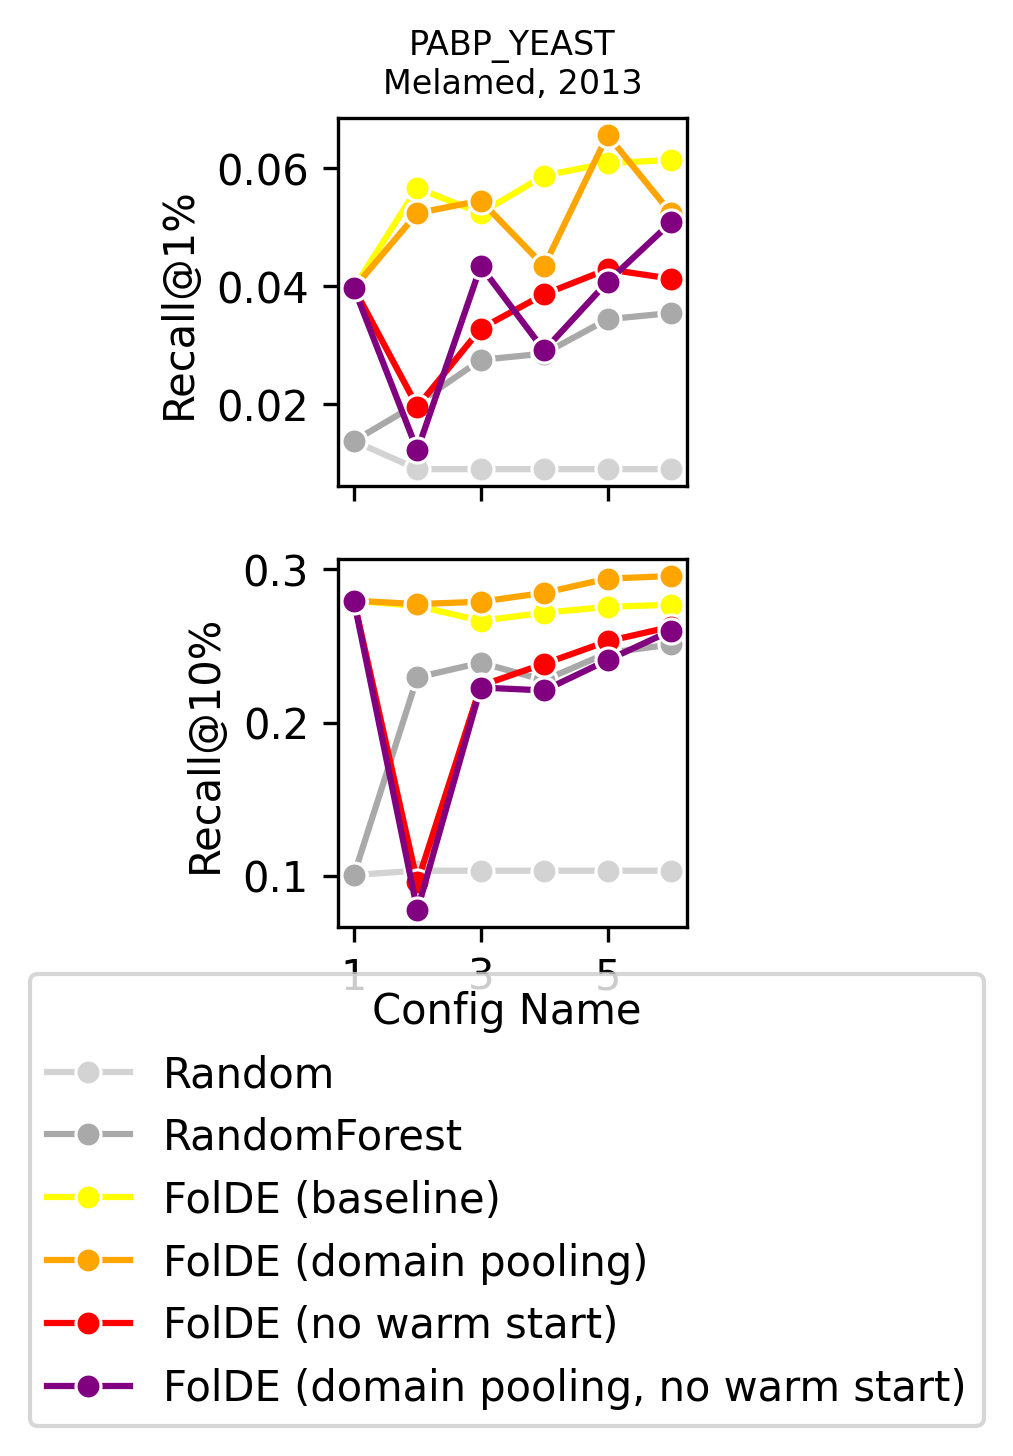

In [12]:
import re

# Get unique dms_ids from the data
dms_ids = round_metrics_df.dms_id.unique()  # round_metrics_df.dms_id.unique()

CONFIG_RENAME_DICT = {
    'Random': 'Random',
    'RandomToRandomForest': 'RandomForest',
    'FolDE-base': 'FolDE (baseline)',
    'FolDE-domainpooling': 'FolDE (domain pooling)',
    'FolDE-nowarmstart': 'FolDE (no warm start)',
    'FolDE-domainpooling-nowarmstart': 'FolDE (domain pooling, no warm start)',
}

PALETTE = {
    'Random': 'lightgrey',
    'RandomForest': 'darkgrey',
    'FolDE (baseline)': 'yellow',
    'FolDE (domain pooling)': 'orange',
    'FolDE (no warm start)': 'red',
    'FolDE (domain pooling, no warm start)': 'purple',
}

# Create subplot grid: 2 rows, len(dms_ids) columns
fig, axes = plt.subplots(2, len(dms_ids), figsize=(len(dms_ids) * 1.5, 3.5), sharex=True, sharey='row', dpi=300)

plot_df = round_metrics_df[round_metrics_df.config_name.isin(CONFIG_RENAME_DICT.keys())].copy()
plot_df['Workflow'] = plot_df.config_name.apply(lambda x: CONFIG_RENAME_DICT[x])
plot_df['Protein Target'] = plot_df.dms_id
plot_df = plot_df[plot_df.round_num <= 6]
# plot_df['workflow'] = plot_df.config_name.apply(lambda x: x.split('-')[0])
# plot_df['benchmark'] = plot_df.config_name.apply(lambda x: '-'.join(x.split('-')[1:]))

metrics = ['held_out_1pct_recall', 'held_out_10pct_recall']#, 'best_percentile_so_far']

for col_idx, dms_id in enumerate(dms_ids):
    dms_data = plot_df[plot_df.dms_id == dms_id]
    
    for row_idx, metric in enumerate(metrics):
        if len(dms_ids) == 1:
            ax = axes[row_idx]
        else:
            ax = axes[row_idx, col_idx]
        sns.lineplot(
            ax=ax,
            data=dms_data,
            y=metric,
            x='round_num',
            hue='Workflow',
            errorbar=None,
            marker='o',
            hue_order=CONFIG_RENAME_DICT.values(),
            palette=PALETTE
        )

        # if row_idx == 2:
        #     ax.set_ylim(0.99, 1)
        
        # Set titles
        if row_idx == 0:
            first_half = '_'.join(dms_id.split('_')[:2])
            second_half = ', '.join(dms_id.split('_')[2:])
            ax.set_title(f'{first_half}\n{second_half}', fontsize=8)
        
        # Set y-labels only for leftmost column
        if col_idx == 0:
            if metric == 'held_out_1pct_recall':
                ax.set_ylabel('Recall@1%')
            else:
                ax.set_ylabel('Recall@10%')
        else:
            ax.set_ylabel('')
        
        # Set x-label only for bottom row
        if row_idx == 1 and col_idx == 1:
            ax.set_xlabel('Round Number')
        else:
            ax.set_xlabel('')
        
        if row_idx == 1:
            ax.set_xticks([1, 3, 5])
        
        # Remove legends from individual subplots
        if ax.get_legend():
            ax.get_legend().remove()
        # ax.axvline(x=2, color='black', linestyle='--')

# Add a single legend for the entire figure
if len(dms_ids) == 1:
    ax = axes[0]
else:
    ax = axes[0, 0]
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Config Name', loc='center', bbox_to_anchor=(0.5, -0.15))#, ncol=len(CONFIGS)//2, fontsize=8)

# plt.tight_layout()